In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [2]:
col_names = ["unit", "time_cycles", "op_set1", "op_set2", "op_set3"] + [f'sensor{i}' for i in range(1, 22)]

df_train= pd.read_csv("CMAPSSData/train_FD001.txt", sep=r"\s+", header=None, names=col_names)
df_test = pd.read_csv("CMAPSSData/test_FD001.txt", sep=r"\s+", header=None, names=col_names)
df_rul = pd.read_csv("CMAPSSData/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])

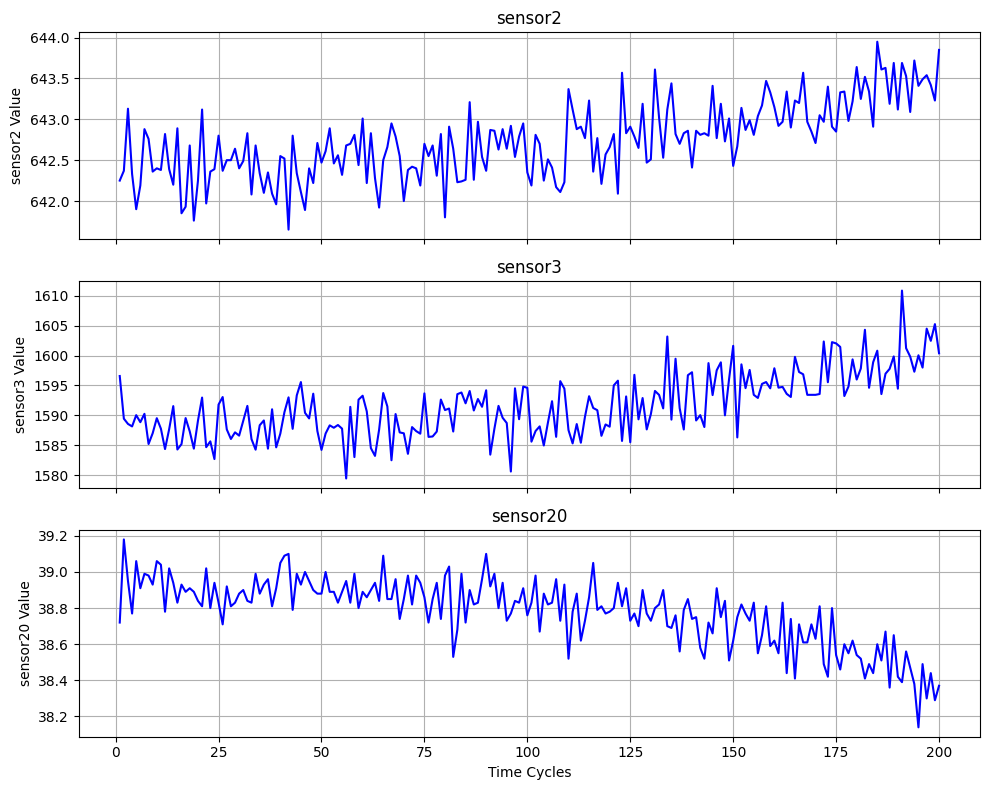

In [ ]:
train_unit_100 = df_train[df_train["unit"] == 100]
test_unit_100 = df_test[df_test["unit"] == 100]
sensors_to_plot = ['sensor1', 'sensor3', 'sensor20']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True)

for i, sensor in enumerate(sensors_to_plot):
    axes[i].plot(train_unit_100["time_cycles"], train_unit_100[sensor], color='blue')
    axes[i].set_ylabel(sensor + " Value")
    axes[i].set_title(sensor)
    axes[i].grid(True) 

axes[-1].set_xlabel("Time Cycles")
plt.tight_layout()
plt.show()

In [ ]:
df_train['RUL'] = df_train.groupby('unit')['time_cycles'].transform(lambda x: x.max() - x) 
#We know max lifetime, so we can use x.max()-x in time cycles for find RUL with grouping by units
df_train

,unit,time_cycles,op_set1,op_set2,op_set3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


In [ ]:
exclude_cols = [f'sensor_{i}' for i in [1, 5, 6, 10, 16, 18, 19]] #Unnecessary(stable) sensors were removed
feature_cols = df_train.filter(regex='sensor').columns.difference(exclude_cols) #op_set not important for FD001

scaler = preprocessing.StandardScaler() #instead of minmax scaler
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols] = scaler.transform(df_test[feature_cols]) # Old fit was used for prevent data leak 

In [17]:
windowing_length = 30

def create_train_sequences(df, seq_len):
    sequences, targets = [], []
    for unit in df['unit'].unique():
        engine_data = df[df['unit'] == unit]
        features = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values

        for i in range(len(features) - seq_len + 1):
            sequences.append(features[i : i + seq_len])
            targets.append(rul_values[i + seq_len - 1]) #RUL values append to targets
            
    return np.array(sequences), np.array(targets)

def get_last_test_windows(df, seq_len):
    last_windows = []
    for unit in df['unit'].unique():
        engine_data = df[df['unit'] == unit]
        features = engine_data[feature_cols].values
        last_windows.append(features[-seq_len:]) #last 30 window important for evaluate RUL
        
    return np.array(last_windows)

In [ ]:
X_train, y_train = create_train_sequences(df_train, windowing_length)
X_test = get_last_test_windows(df_test, windowing_length)

y_test = df_rul.values

print(f"X_train: {X_train.shape}") 
print(f"Y_train: {y_train.shape}")   
print(f"X_test: {X_test.shape}")    
print(f"y_test: {y_test.shape}")    

X_train: (17731, 30, 21)
Y_train: (17731,)
X_test: (100, 30, 21)
y_test: (100, 1)
